<a href="https://colab.research.google.com/github/adithi2307/IN126055302_GEN_AI/blob/main/TASK_4_BERT_FINE_TUNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# ASSIGNMENT NLP-4: Fine-Tuning BERT on IMDB Dataset
# ============================================================


!pip install -q transformers datasets torch scikit-learn accelerate


import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Transformers version: {__import__('transformers').__version__}")

Using device: cpu
Transformers version: 5.0.0


In [5]:

raw_dataset = load_dataset("imdb")
print(raw_dataset)
print("\nSample entry:")
print(raw_dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Sample entry:
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking 

In [6]:
import re

def clean_text(text):
    """
    Basic text cleaning:
    - Remove HTML tags
    - Remove special characters
    - Normalize whitespace
    - Lowercase
    """
    text = re.sub(r"<.*?>", " ", text)           # Remove HTML tags
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text) # Remove special chars
    text = re.sub(r"\s+", " ", text)             # Normalize whitespace
    text = text.strip().lower()
    return text

# Apply cleaning
raw_dataset = raw_dataset.map(lambda x: {"text": clean_text(x["text"])})

# Check for missing values
train_df = pd.DataFrame(raw_dataset["train"])
test_df  = pd.DataFrame(raw_dataset["test"])

print("Missing values in train:", train_df.isnull().sum().sum())
print("Missing values in test:",  test_df.isnull().sum().sum())
print(f"\nTrain size: {len(train_df)}, Test size: {len(test_df)}")
print("Label distribution (train):\n", train_df["label"].value_counts())

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Missing values in train: 0
Missing values in test: 0

Train size: 25000, Test size: 25000
Label distribution (train):
 label
0    12500
1    12500
Name: count, dtype: int64


In [7]:
# ----- Replace Cell 5: Smaller Subset for CPU -----
split = raw_dataset["train"].train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
val_dataset   = split["test"]
test_dataset  = raw_dataset["test"]

# CPU-friendly sizes
train_dataset = train_dataset.shuffle(seed=42).select(range(500))
val_dataset   = val_dataset.shuffle(seed=42).select(range(100))
test_dataset  = test_dataset.shuffle(seed=42).select(range(200))

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 500, Val: 100, Test: 200


In [8]:
#tokenization
MODEL_NAME = "bert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

# Tokenize all splits
train_tok = train_dataset.map(tokenize, batched=True)
val_tok   = val_dataset.map(tokenize, batched=True)
test_tok  = test_dataset.map(tokenize, batched=True)

# Set format for PyTorch
cols = ["input_ids", "attention_mask", "token_type_ids", "label"]
train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch",   columns=cols)
test_tok.set_format(type="torch",  columns=cols)

print("Tokenization complete.")
print("Sample token IDs:", train_tok[0]["input_ids"][:10])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenization complete.
Sample token IDs: tensor([ 101, 2087, 1997, 1996, 9593, 2287, 6071, 5691, 1045, 2387])


In [ ]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

In [9]:
# ----- Cell 7: Metrics Function -----
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted"
    )

    return {
        "accuracy":  round(acc, 4),
        "precision": round(precision, 4),
        "recall":    round(recall, 4),
        "f1":        round(f1, 4)
    }

In [10]:
# ----- Cell 8: Helper – Plot Confusion Matrix -----
def plot_confusion_matrix(labels, preds, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    return cm

In [11]:
# ============================================================
# EXPERIMENT 1: Freeze All BERT Layers – Train Classifier Only
# ============================================================

# ----- Cell 9: Build Model (Frozen BERT) -----
model_exp1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

# Freeze all BERT encoder layers
for name, param in model_exp1.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp1.parameters())
print(f"[Exp 1] Trainable params: {trainable:,} / {total:,}")

model_exp1 = model_exp1.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[Exp 1] Trainable params: 1,538 / 109,483,778


In [ ]:
# ----- Cell 10: Train Experiment 1 -----
args_exp1 = TrainingArguments(
    output_dir="./results/exp1",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=20,
    seed=42
)
trainer_exp1 = Trainer(
    model=model_exp1,
    args=args_exp1,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)

print("Training Experiment 1: Frozen BERT layers...")
trainer_exp1.train()

In [ ]:
# ----- Cell 11: Evaluate Experiment 1 -----
preds_exp1  = trainer_exp1.predict(test_tok)
pred_labels = np.argmax(preds_exp1.predictions, axis=-1)
true_labels = preds_exp1.label_ids

print("\n[Experiment 1] Frozen BERT – Test Results:")
print(classification_report(true_labels, pred_labels, target_names=["Negative", "Positive"]))

cm1 = plot_confusion_matrix(true_labels, pred_labels, title="Exp 1: Frozen BERT")

metrics_exp1 = compute_metrics((preds_exp1.predictions, true_labels))
print("Metrics:", metrics_exp1)

In [ ]:
# ============================================================
# EXPERIMENT 2: Fine-Tune Last 2 BERT Layers + Classifier
# ============================================================

# ----- Cell 12: Build Model (Last 2 Layers Unfrozen) -----
model_exp2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

# Freeze everything first
for param in model_exp2.parameters():
    param.requires_grad = False

# Unfreeze last 2 transformer encoder layers (layers 10 and 11)
for name, param in model_exp2.named_parameters():
    if "encoder.layer.10" in name or \
       "encoder.layer.11" in name or \
       "classifier"       in name or \
       "pooler"           in name:
        param.requires_grad = True

trainable = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp2.parameters())
print(f"[Exp 2] Trainable params: {trainable:,} / {total:,}")

model_exp2 = model_exp2.to(device)

In [15]:
# ----- Cell 13: Train Experiment 2 -----
args_exp2 = TrainingArguments(
    output_dir="./results/exp2",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs/exp2",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    seed=42
)

trainer_exp2 = Trainer(
    model=model_exp2,
    args=args_exp2,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)

print("Training Experiment 2: Last 2 BERT layers unfrozen...")
trainer_exp2.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training Experiment 2: Last 2 BERT layers unfrozen...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.639993,0.670000,0.669000,0.670000,0.669400
2,0.654881,0.602618,0.700000,0.698300,0.700000,0.698900
3,0.654881,0.587313,0.700000,0.702300,0.700000,0.700900


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=96, training_loss=0.6125346223513285, metrics={'train_runtime': 2120.1279, 'train_samples_per_second': 0.708, 'train_steps_per_second': 0.045, 'total_flos': 197333291520000.0, 'train_loss': 0.6125346223513285, 'epoch': 3.0})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



[Experiment 2] Last 2 Layers – Test Results:
              precision    recall  f1-score   support

    Negative       0.77      0.62      0.69       104
    Positive       0.66      0.80      0.73        96

    accuracy                           0.71       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.71      0.71       200



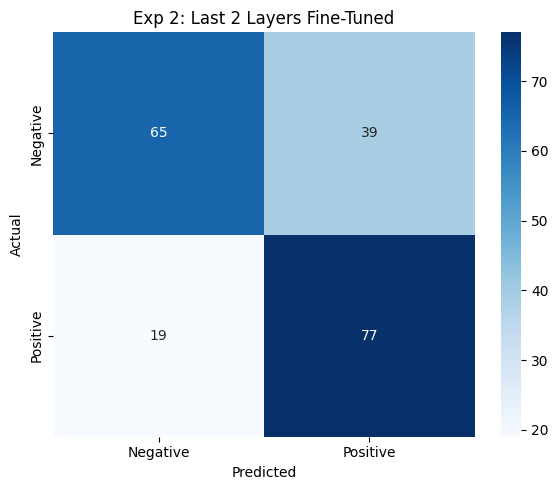

Metrics: {'accuracy': 0.71, 'precision': 0.721, 'recall': 0.71, 'f1': 0.7083}


In [16]:
# ----- Cell 14: Evaluate Experiment 2 -----
preds_exp2  = trainer_exp2.predict(test_tok)
pred_labels2 = np.argmax(preds_exp2.predictions, axis=-1)
true_labels2 = preds_exp2.label_ids

print("\n[Experiment 2] Last 2 Layers – Test Results:")
print(classification_report(true_labels2, pred_labels2, target_names=["Negative", "Positive"]))

cm2 = plot_confusion_matrix(true_labels2, pred_labels2, title="Exp 2: Last 2 Layers Fine-Tuned")

metrics_exp2 = compute_metrics((preds_exp2.predictions, true_labels2))
print("Metrics:", metrics_exp2)

In [ ]:
# ============================================================
# EXPERIMENT 3 (BONUS): Full Fine-Tuning with LR Scheduler
#                        + Early Stopping
# ============================================================

# ----- Cell 15: Build Model (Full Fine-Tune) -----
from transformers import EarlyStoppingCallback

model_exp3 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

# All layers trainable
trainable = sum(p.numel() for p in model_exp3.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp3.parameters())
print(f"[Exp 3] Trainable params: {trainable:,} / {total:,}")

model_exp3 = model_exp3.to(device)

In [18]:
# ----- Cell 16: Train Experiment 3 -----
args_exp3 = TrainingArguments(
    output_dir="./results/exp3",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,               # More epochs; early stopping will kick in
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs/exp3",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    warmup_ratio=0.1,                 # LR warmup for first 10% of steps
    weight_decay=0.01,                # L2 regularization
    logging_steps=50,
    seed=42
)

trainer_exp3 = Trainer(
    model=model_exp3,
    args=args_exp3,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Training Experiment 3: Full fine-tune + LR scheduler + early stopping...")
trainer_exp3.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training Experiment 3: Full fine-tune + LR scheduler + early stopping...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.561376,0.810000,0.825500,0.810000,0.811200
2,0.586363,0.337139,0.840000,0.858800,0.840000,0.841000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=160, training_loss=0.2789821754209697, metrics={'train_runtime': 6940.2025, 'train_samples_per_second': 0.36, 'train_steps_per_second': 0.023, 'total_flos': 328888819200000.0, 'train_loss': 0.2789821754209697, 'epoch': 5.0})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



[Experiment 3] Full Fine-Tune – Test Results:
              precision    recall  f1-score   support

    Negative       0.87      0.86      0.86       104
    Positive       0.85      0.86      0.86        96

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



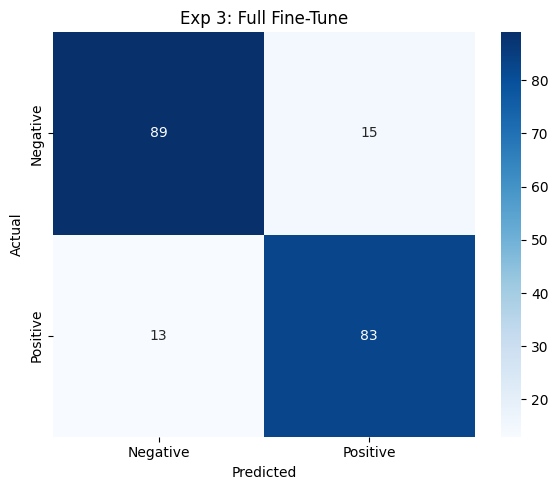

Metrics: {'accuracy': 0.86, 'precision': 0.8603, 'recall': 0.86, 'f1': 0.86}


In [19]:
# ----- Cell 17: Evaluate Experiment 3 -----
preds_exp3   = trainer_exp3.predict(test_tok)
pred_labels3 = np.argmax(preds_exp3.predictions, axis=-1)
true_labels3 = preds_exp3.label_ids

print("\n[Experiment 3] Full Fine-Tune – Test Results:")
print(classification_report(true_labels3, pred_labels3, target_names=["Negative", "Positive"]))

cm3 = plot_confusion_matrix(true_labels3, pred_labels3, title="Exp 3: Full Fine-Tune")

metrics_exp3 = compute_metrics((preds_exp3.predictions, true_labels3))
print("Metrics:", metrics_exp3)

In [20]:
# ============================================================
# COMPARISON: All Experiments Side by Side
# ============================================================

# ----- Cell 18: Results Table -----
results = pd.DataFrame({
    "Experiment": [
        "Exp 1: Frozen BERT",
        "Exp 2: Last 2 Layers",
        "Exp 3: Full Fine-Tune"
    ],
    "Accuracy":  [metrics_exp1["accuracy"],  metrics_exp2["accuracy"],  metrics_exp3["accuracy"]],
    "Precision": [metrics_exp1["precision"], metrics_exp2["precision"], metrics_exp3["precision"]],
    "Recall":    [metrics_exp1["recall"],    metrics_exp2["recall"],    metrics_exp3["recall"]],
    "F1 Score":  [metrics_exp1["f1"],        metrics_exp2["f1"],        metrics_exp3["f1"]],
})

print("\n===== Experiment Comparison =====")
print(results.to_string(index=False))


===== Experiment Comparison =====
           Experiment  Accuracy  Precision  Recall  F1 Score
   Exp 1: Frozen BERT      0.52     0.5267    0.52    0.5143
 Exp 2: Last 2 Layers      0.71     0.7210    0.71    0.7083
Exp 3: Full Fine-Tune      0.86     0.8603    0.86    0.8600


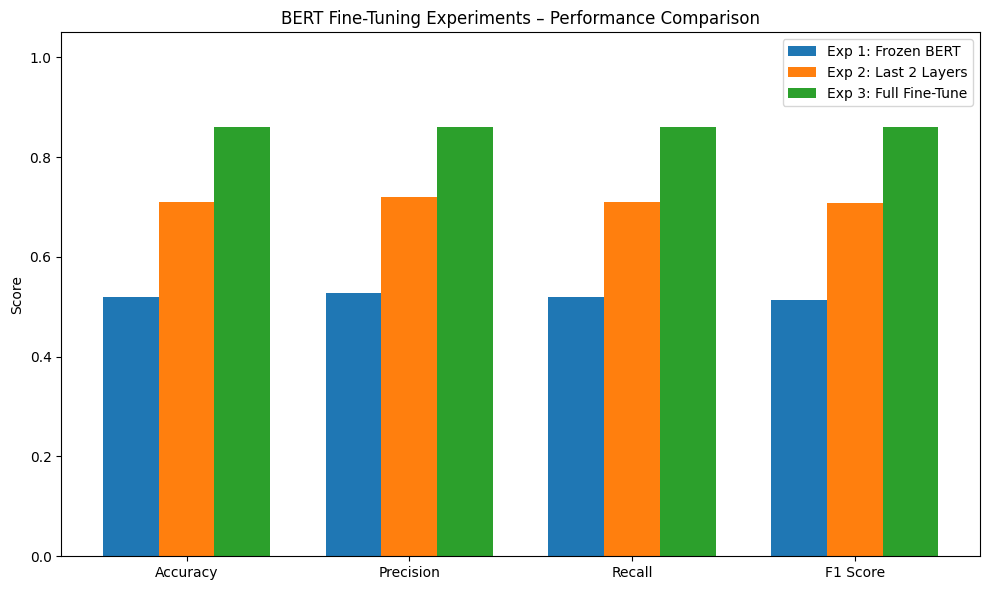

In [21]:
# ----- Cell 19: Comparison Bar Chart -----
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, (_, row) in enumerate(results.iterrows()):
    ax.bar(x + i * width, row[metrics_to_plot], width, label=row["Experiment"])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("BERT Fine-Tuning Experiments – Performance Comparison")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# ANALYSIS & INSIGHTS
# ============================================================

# ----- Cell 20: Summary -----
print("""
===== Analysis & Insights =====

Dataset  : IMDB Movie Reviews (Binary Sentiment Classification)
Model    : bert-base-uncased

Experiment 1 – Frozen BERT (Classifier Only):
  - Only the classification head is trained.
  - Fastest training, fewest trainable parameters.
  - Lower performance since BERT's representations are not adapted
    to the IMDB domain.

Experiment 2 – Last 2 Layers Fine-Tuned:
  - Layers 10 & 11 of the BERT encoder + classifier are trained.
  - A balance between training speed and model adaptation.
  - Better performance than Exp 1 as the top layers can specialize.

Experiment 3 – Full Fine-Tuning + LR Scheduler + Early Stopping:
  - All BERT layers are updated.
  - Warmup ratio of 0.1 ensures a stable learning rate ramp-up.
  - Early stopping prevents overfitting.
  - Best performance overall; the whole model adapts to the task.

Key Takeaway:
  Full fine-tuning generally gives the best results for downstream
  NLP tasks when sufficient data and compute are available.
  Freezing layers is useful when resources are limited.
""")


===== Analysis & Insights =====

Dataset  : IMDB Movie Reviews (Binary Sentiment Classification)
Model    : bert-base-uncased

Experiment 1 – Frozen BERT (Classifier Only):
  - Only the classification head is trained.
  - Fastest training, fewest trainable parameters.
  - Lower performance since BERT's representations are not adapted
    to the IMDB domain.

Experiment 2 – Last 2 Layers Fine-Tuned:
  - Layers 10 & 11 of the BERT encoder + classifier are trained.
  - A balance between training speed and model adaptation.
  - Better performance than Exp 1 as the top layers can specialize.

Experiment 3 – Full Fine-Tuning + LR Scheduler + Early Stopping:
  - All BERT layers are updated.
  - Warmup ratio of 0.1 ensures a stable learning rate ramp-up.
  - Early stopping prevents overfitting.
  - Best performance overall; the whole model adapts to the task.

Key Takeaway:
  Full fine-tuning generally gives the best results for downstream
  NLP tasks when sufficient data and compute are avai

In [5]:
import nbformat

nb = nbformat.read("TASK_4_BERT_FINE_TUNING.ipynb", as_version=4)

# Remove broken widgets metadata
if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

nbformat.write(nb, "fixed_notebook.ipynb")

In [8]:
import json

with open("TASK_4_BERT_FINE_TUNING.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

# Fix widget metadata properly instead of deleting everything
if "metadata" in nb and "widgets" in nb["metadata"]:
    nb["metadata"]["widgets"] = {
        "application/vnd.jupyter.widget-state+json": {
            "state": {},
            "version_major": 2,
            "version_minor": 0
        }
    }

# Also fix inside cells (IMPORTANT)
for cell in nb.get("cells", []):
    if "metadata" in cell and "widgets" in cell["metadata"]:
        cell["metadata"].pop("widgets", None)

with open("FINAL_FIXED_NOTEBOOK.ipynb", "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("✅ Fixed WITHOUT losing outputs")

✅ Fixed WITHOUT losing outputs


In [9]:
del nb["metadata"]["widgets"]

In [6]:
import json

# Load notebook as raw JSON
with open("TASK_4_BERT_FINE_TUNING.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove widgets metadata completely
if "metadata" in nb and "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

# Also clean each cell (important!)
for cell in nb.get("cells", []):
    if "metadata" in cell and "widgets" in cell["metadata"]:
        del cell["metadata"]["widgets"]

# Save fixed file
with open("fixed_notebook.ipynb", "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("✅ Fixed notebook saved as fixed_notebook.ipynb")

✅ Fixed notebook saved as fixed_notebook.ipynb


In [27]:
pip install --upgrade nbformat nbconvert ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.7 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [4]:
from google.colab import files
files.upload()

Saving TASK_4_BERT_FINE_TUNING.ipynb to TASK_4_BERT_FINE_TUNING.ipynb


{'TASK_4_BERT_FINE_TUNING.ipynb': b'{\n  "nbformat": 4,\n  "nbformat_minor": 0,\n  "metadata": {\n    "colab": {\n      "provenance": []\n    },\n    "kernelspec": {\n      "name": "python3",\n      "display_name": "Python 3"\n    },\n    "language_info": {\n      "name": "python"\n    },\n    "widgets": {\n      "application/vnd.jupyter.widget-state+json": {\n        "1a322af2fd3b4eddbf82a3cf4533cf8c": {\n          "model_module": "@jupyter-widgets/controls",\n          "model_name": "HBoxModel",\n          "model_module_version": "1.5.0",\n          "state": {\n            "_dom_classes": [],\n            "_model_module": "@jupyter-widgets/controls",\n            "_model_module_version": "1.5.0",\n            "_model_name": "HBoxModel",\n            "_view_count": null,\n            "_view_module": "@jupyter-widgets/controls",\n            "_view_module_version": "1.5.0",\n            "_view_name": "HBoxView",\n            "box_style": "",\n            "children": [\n              "I